In [1]:
from src import *

In [11]:
di_ideal = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d0_raw.npy')
di_noisy = np.load(r'raw\noisy\di_5px\di_5px_f0.2_d42_raw.npy')


pm_ideal = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d0_raw.npy')
pm_noisy = np.load(r'raw\noisy\spade_5px\spade_5px_f0.2_d92_raw.npy')

# di_ideal = np.load(r'raw\ideal\di_5px\di_5px_f0.1_d0_raw.npy')
# di_noisy = np.load(r'raw\ideal\di_5px\di_5px_f0.4_d0_raw.npy')


# pm_ideal = np.load(r'raw\ideal\spade_5px\spade_5px_f0.1_d0_raw.npy')
# pm_noisy = np.load(r'raw\ideal\spade_5px\spade_5px_f0.4_d0_raw.npy')

In [12]:
raw = {
    'di_ideal': {'0': qCMOS.convert2photons(di_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_ideal[0, 4, :-4, :].astype(float), 0)},

    'di_noisy': {'0': qCMOS.convert2photons(di_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(di_noisy[0, 4, :-4, :].astype(float), 0)},

    'pm_ideal': {'0': qCMOS.convert2photons(pm_ideal[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_ideal[0, 4, :-4, :].astype(float), 0)},

    'pm_noisy': {'0': qCMOS.convert2photons(pm_noisy[0, 0, :-4, :].astype(float), 0),
                '2a': qCMOS.convert2photons(pm_noisy[0, 4, :-4, :].astype(float), 0)},
}


limit = {
    'di_ideal': {'vmin': min(raw['di_ideal']['0'].min(), raw['di_ideal']['2a'].min()),
                 'vmax': max(raw['di_ideal']['0'].max(), raw['di_ideal']['2a'].max())},

    'di_noisy': {'vmin': min(raw['di_noisy']['0'].min(), raw['di_noisy']['2a'].min()),
                 'vmax': max(raw['di_noisy']['0'].max(), raw['di_noisy']['2a'].max())},

    'pm_ideal': {'vmin': min(raw['pm_ideal']['0'].min(), raw['pm_ideal']['2a'].min()),
                 'vmax': max(raw['pm_ideal']['0'].max(), raw['pm_ideal']['2a'].max())},

    'pm_noisy': {'vmin': min(raw['pm_noisy']['0'].min(), raw['pm_noisy']['2a'].min()),
                 'vmax': max(raw['pm_noisy']['0'].max(), raw['pm_noisy']['2a'].max())},
}

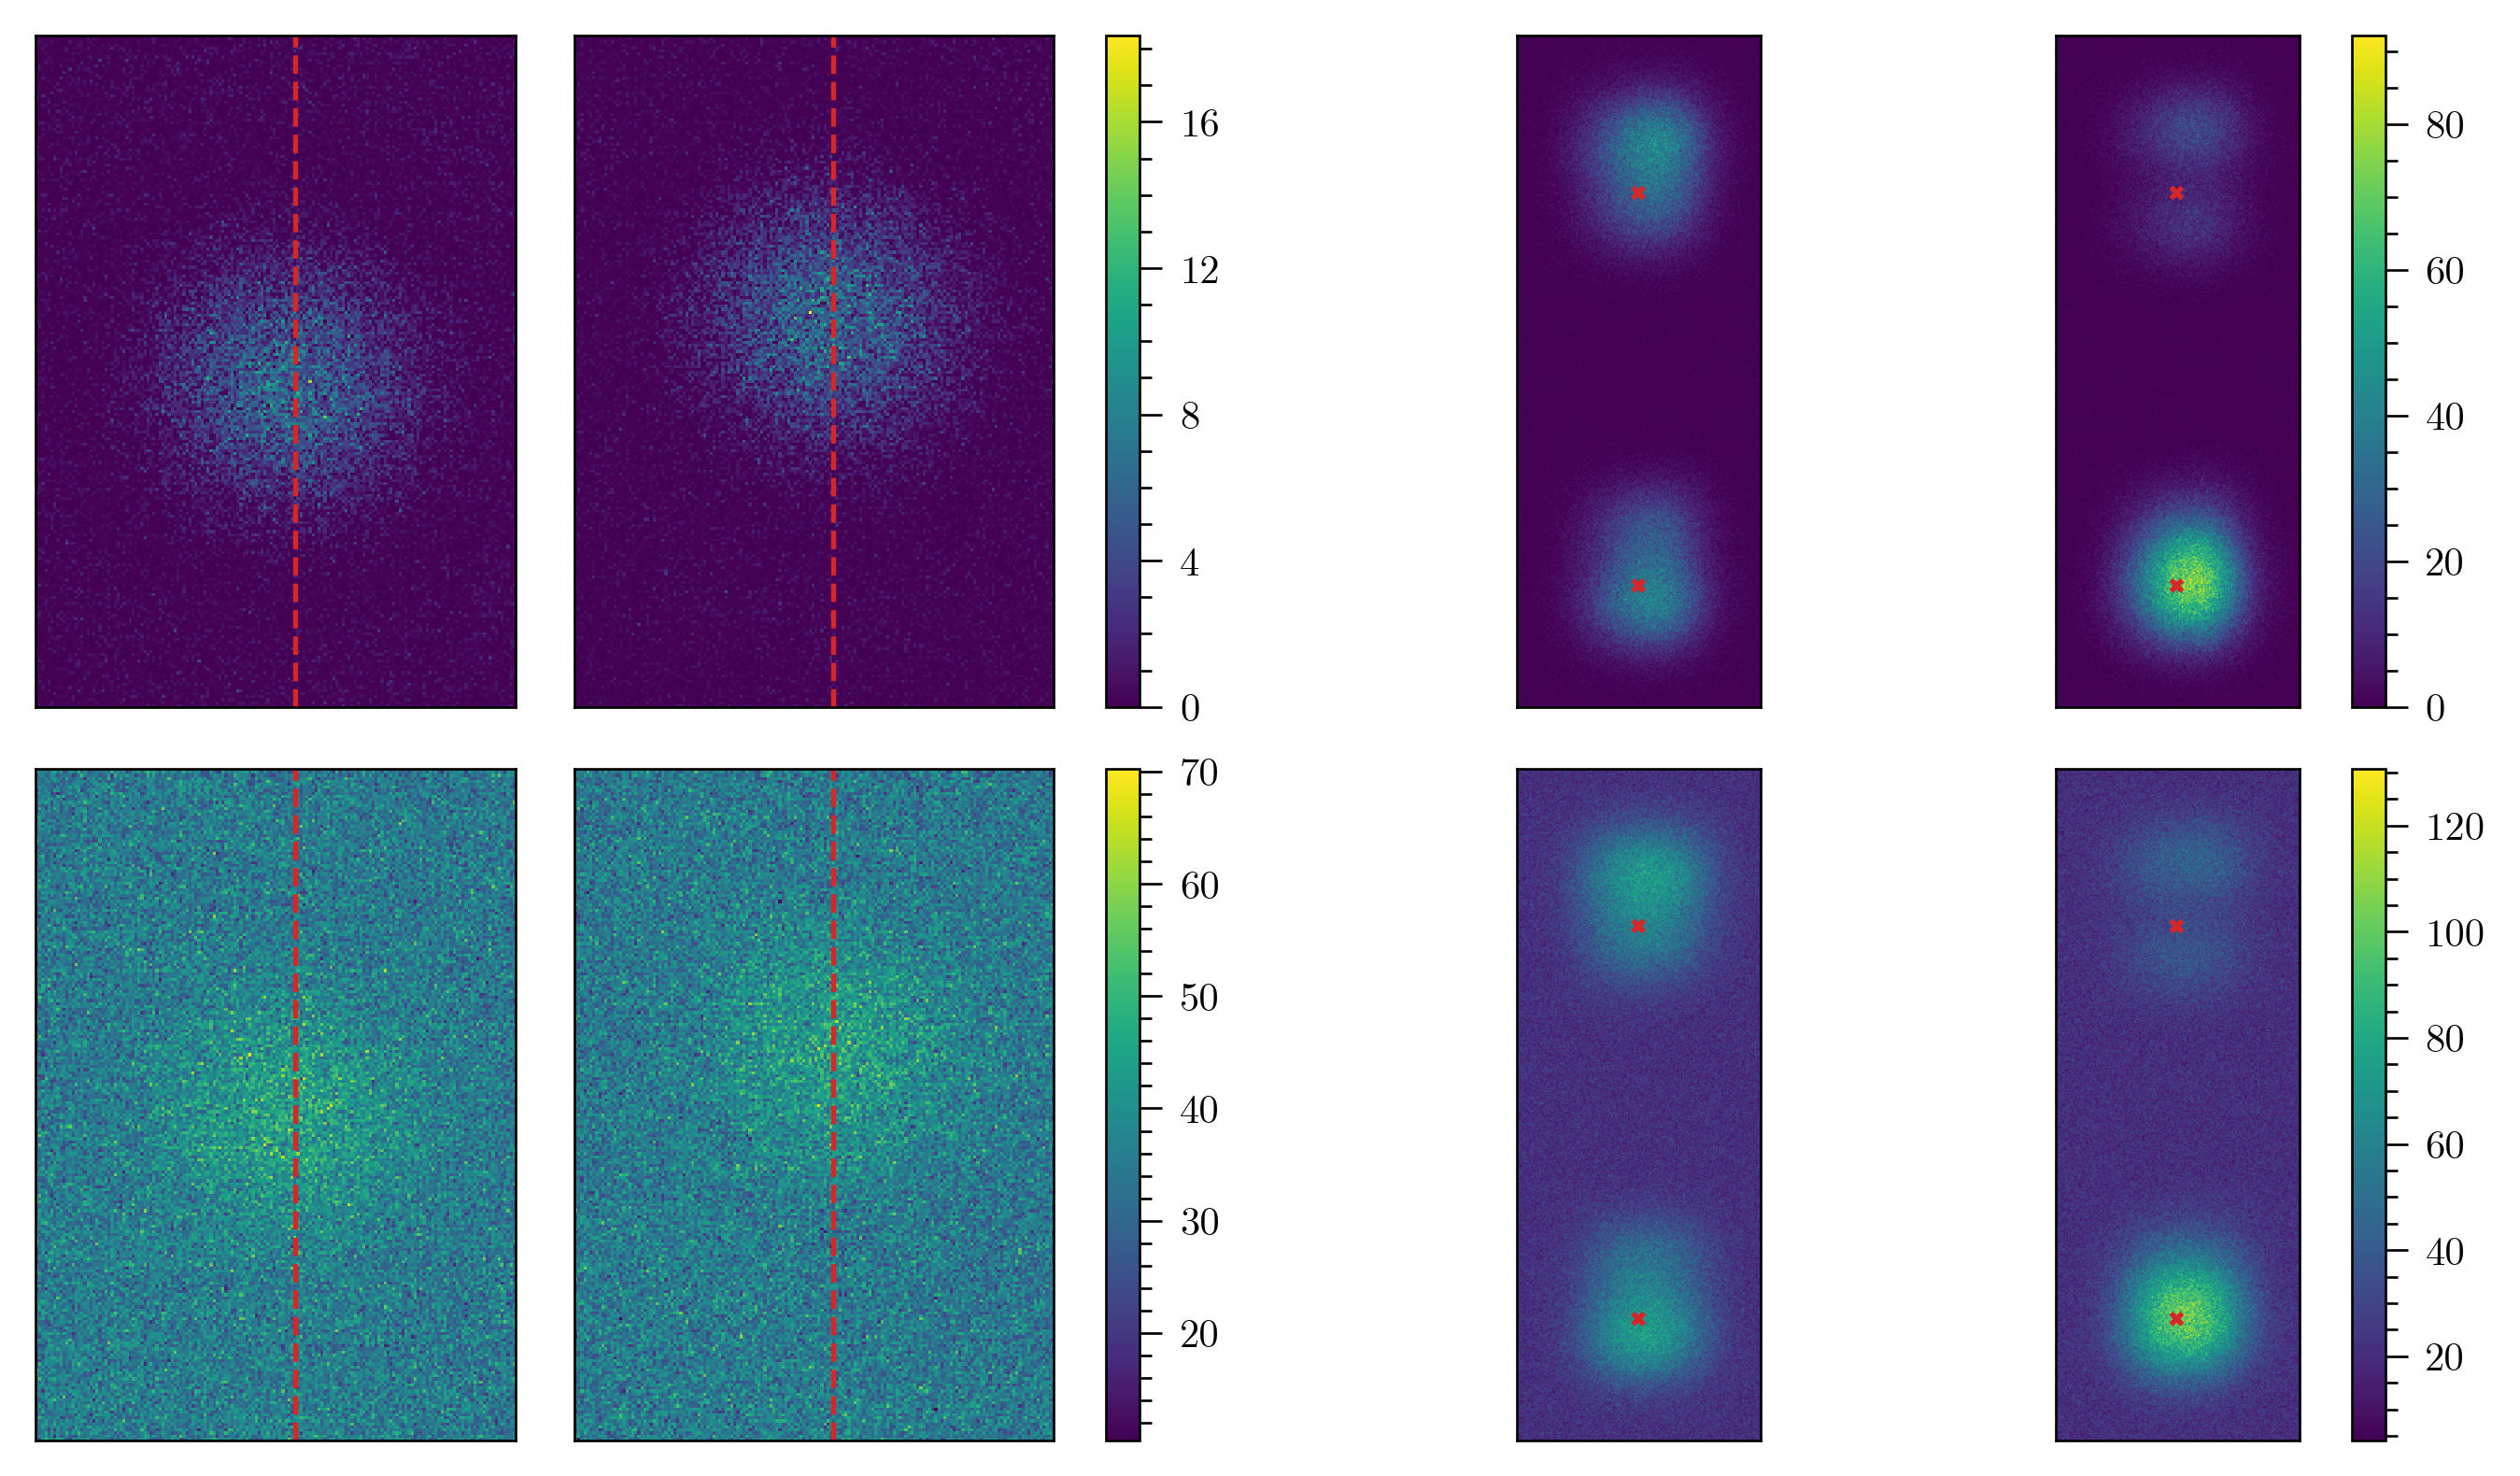

In [25]:
fig, axs = plt.subplots(2, 4, figsize=(7, 4), constrained_layout=True)
axs = np.ravel(axs)

axs[0].imshow(raw['di_ideal']['0'], **limit['di_ideal'])
im1 = axs[1].imshow(raw['di_ideal']['2a'], **limit['di_ideal'])

axs[2].imshow(raw['pm_ideal']['0'], **limit['pm_ideal'])
im2 = axs[3].imshow(raw['pm_ideal']['2a'], **limit['pm_ideal'])

axs[4].imshow(raw['di_noisy']['0'], **limit['di_noisy'])
im3 = axs[5].imshow(raw['di_noisy']['2a'], **limit['di_noisy'])

axs[6].imshow(raw['pm_noisy']['0'], **limit['pm_noisy'])
im4 = axs[7].imshow(raw['pm_noisy']['2a'], **limit['pm_noisy'])

for i in [0, 1, 4, 5]:
    axs[i].axvline(DI.X_AXIS, color='tab:red', linestyle='--')

for i in [2, 3, 6, 7]:
    axs[i].scatter([SPADE.X_AXIS]*2, [SPADE.POINT_1, SPADE.POINT_2], color='tab:red', marker='X', edgecolor='none')

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im1, ax=[axs[0], axs[1]], ticks=np.arange(0, 18, 4))
fig.colorbar(im2, ax=[axs[2], axs[3]])
fig.colorbar(im3, ax=[axs[4], axs[5]])
fig.colorbar(im4, ax=[axs[6], axs[7]])

# axs[0].text(-0.1, 0.5, 'High SNR\n'+r'$(b/\nu\approx 0)$', va='center', ha='right', fontsize=8, transform=axs[0].transAxes)
# axs[4].text(-0.1, 0.5, 'Low SNR\n'+r'$(b/\nu\approx 0.1)$', va='center', ha='right', fontsize=8, transform=axs[4].transAxes)

# plt.savefig('imshow.pdf')
plt.show()

In [102]:
from scipy.stats import norm

In [136]:
binned_1 = qCMOS.convert2photons(di_c.cropped_data[0, 0], 0).reshape(-1, 8)

In [139]:
binned_1.sum(-1)

array([688.93, 680.68, 707.52, 635.69, 669.79, 710.93, 722.04, 704.22,
       665.72, 720.39, 700.15, 691.79, 692.78, 777.26, 758.34, 779.46,
       691.13, 726.11, 752.18, 682.11, 729.85, 679.91, 666.93, 719.84,
       755.59])

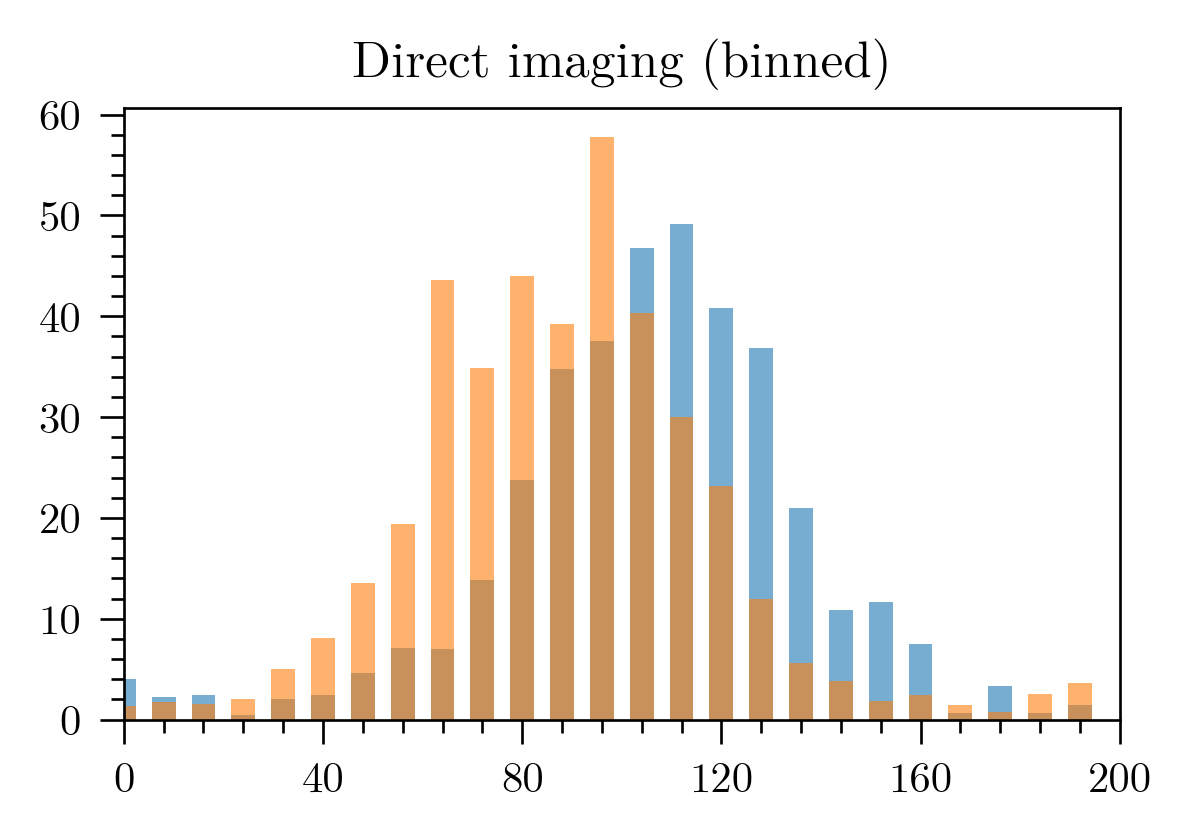

In [166]:
di_c = LoadEstimates('data/noisy/di_5px_f0.2_d0.npz')

binned_1 = qCMOS.convert2photons(di_c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
binned_2 = qCMOS.convert2photons(di_c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

plt.bar(np.arange(25), binned_1, alpha=0.6, edgecolor='none', width=0.6, label=r'$0$')
plt.bar(np.arange(25), binned_2, alpha=0.6, edgecolor='none', width=0.6, label=r'$-2A$')

# plt.plot(np.arange(200), qCMOS.convert2photons(di_c.cropped_data[0, 0], 0), alpha=0.6, label=r'$0$')
# plt.plot(np.arange(200), qCMOS.convert2photons(di_c.cropped_data[0, 4], 0), alpha=0.6, label=r'$-2A$')

# gaus_param = (di_c.time_domain[0, 0] / qCMOS.PIXEL_SIZE + DI.CENTER, DI.SIGMA / qCMOS.PIXEL_SIZE)
# plt.plot(np.arange(0, 200, 0.1), di_c.photons*norm(*gaus_param).pdf(np.arange(0, 200, 0.1)), color='tab:blue')

# gaus_param = (di_c.time_domain[0, 4] / qCMOS.PIXEL_SIZE + DI.CENTER, DI.SIGMA / qCMOS.PIXEL_SIZE)
# plt.plot(np.arange(0, 200, 0.1), di_c.photons*norm(*gaus_param).pdf(np.arange(0, 200, 0.1)), color='tab:orange')

plt.xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))
plt.xlim(0, 25)
plt.title('Direct imaging (binned)')

# plt.legend()
plt.show()

In [175]:
def binning(c):
    binned_1 = qCMOS.convert2photons(c.cropped_data[0, 0], 0).reshape(-1, 8).sum(-1)
    binned_2 = qCMOS.convert2photons(c.cropped_data[0, 4], 0).reshape(-1, 8).sum(-1)

    return binned_1, binned_2

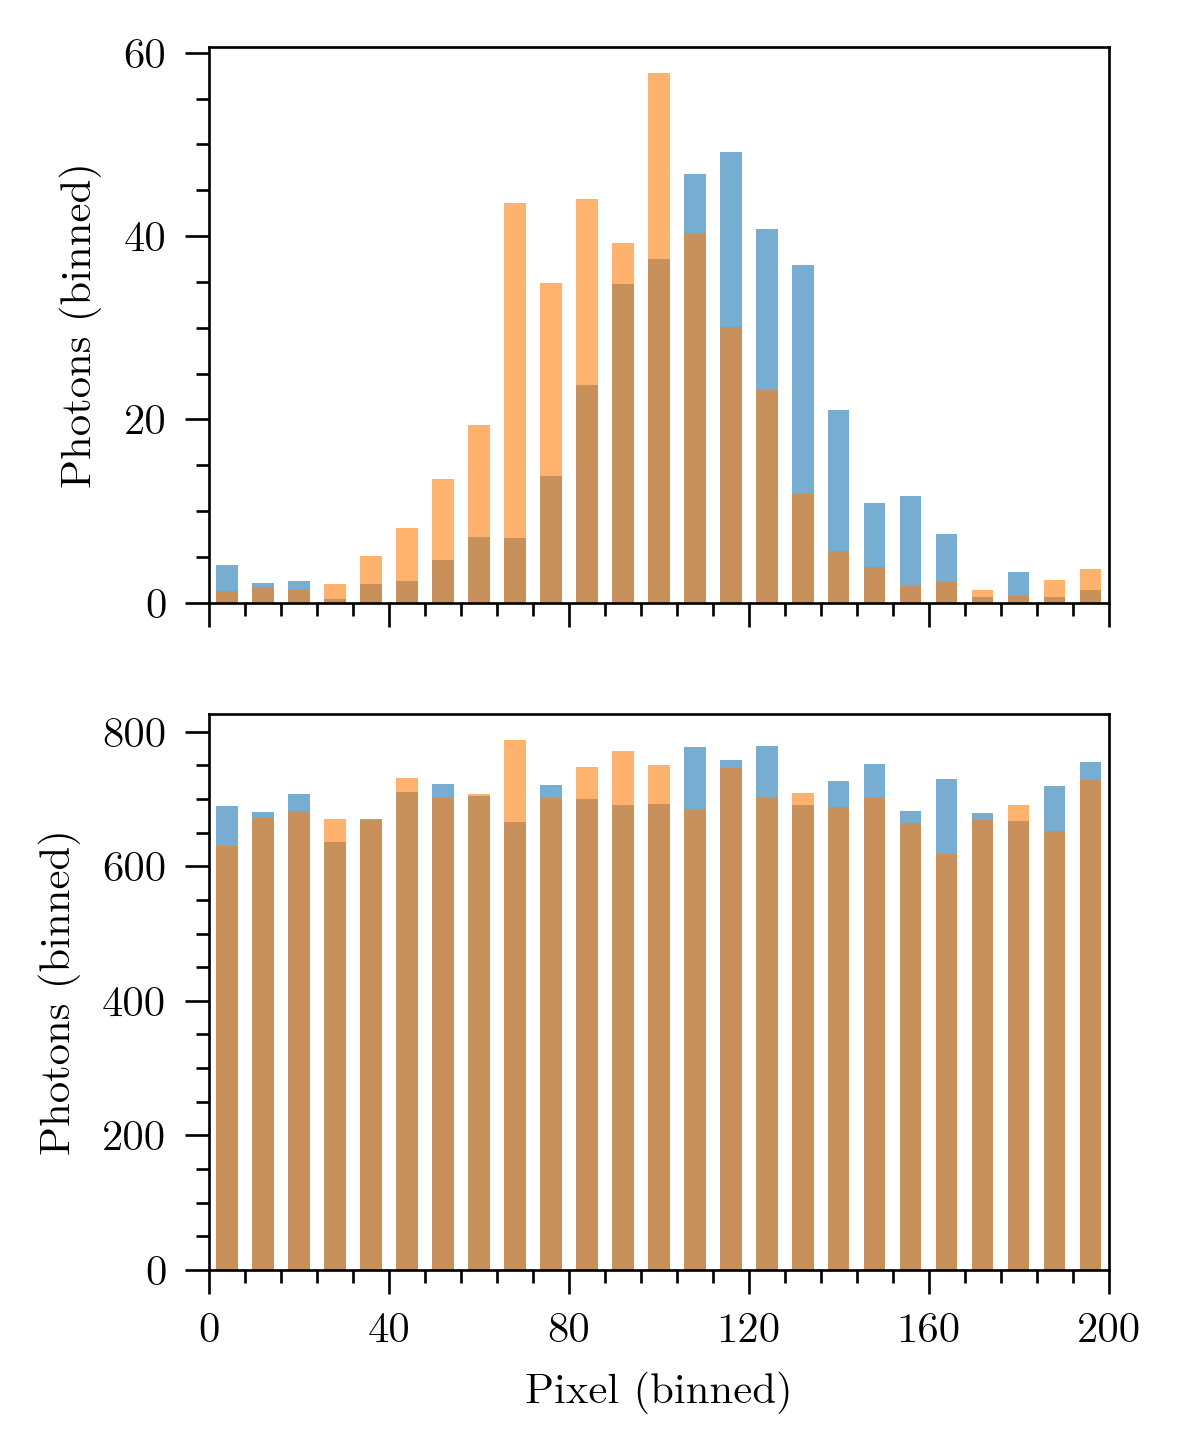

In [201]:
fig, axes = plt.subplots(2, 1, figsize=(8.5 / 2.54, 2*0.618 * 8.5 / 2.54), sharex=True)


binned_1, binned_2 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d0.npz'))
binned_3, binned_4 = binning(LoadEstimates('data/noisy/di_5px_f0.2_d92.npz'))

axes[0].bar(np.arange(25)+0.5, binned_1, alpha=0.6, edgecolor='none', width=0.6, label=r'$0$')
axes[0].bar(np.arange(25)+0.5, binned_2, alpha=0.6, edgecolor='none', width=0.6, label=r'$-2A$')

axes[1].bar(np.arange(25)+0.5, binned_3, alpha=0.6, edgecolor='none', width=0.6, label=r'$0$')
axes[1].bar(np.arange(25)+0.5, binned_4, alpha=0.6, edgecolor='none', width=0.6, label=r'$-2A$')


for ax in axes.ravel():
    ax.set_box_aspect(0.618)
    ax.set_xlim(0, 25)
    ax.set_xticks(np.linspace(0, 25, 6), np.linspace(0, 200, 6).astype(int))

axes[1].set_xlabel('Pixel (binned)')
axes[0].set_ylabel('Photons (binned)')
axes[1].set_ylabel('Photons (binned)')

plt.show()

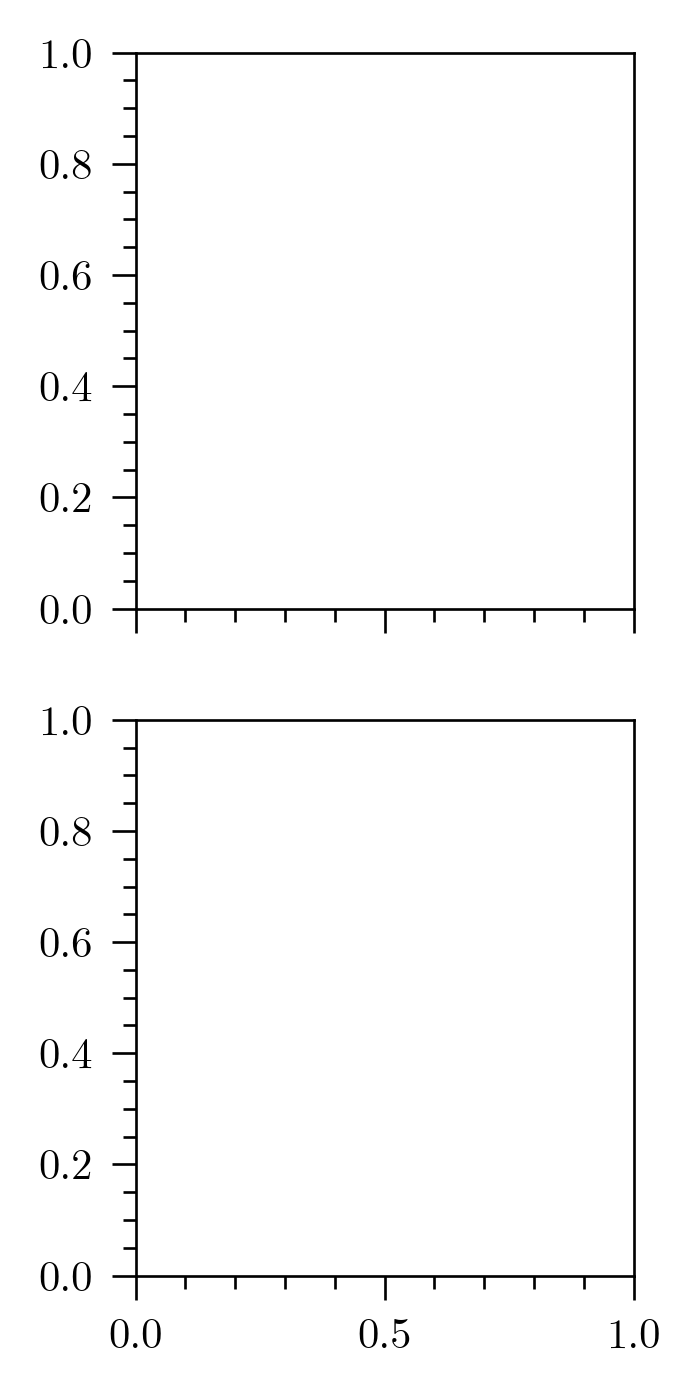

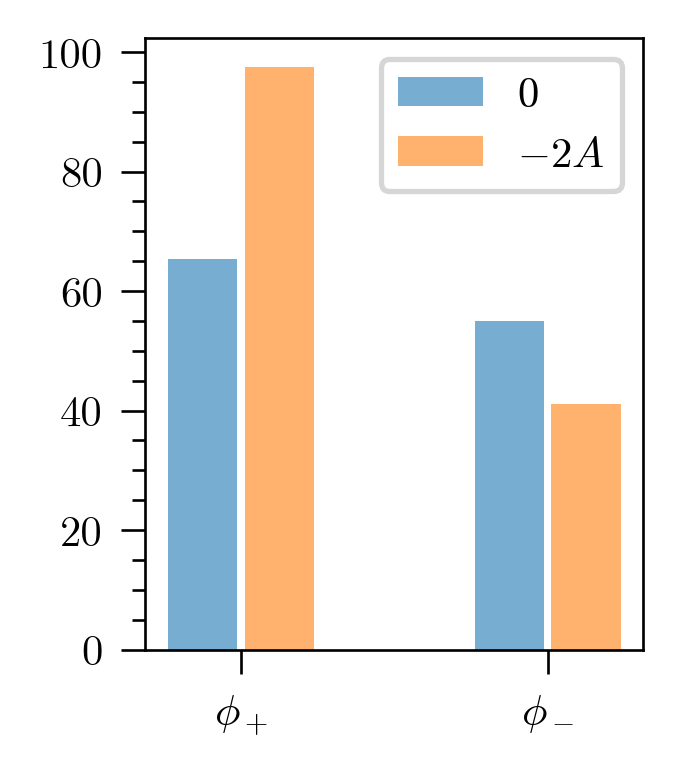

In [202]:
fig, axs = plt.subplots(2, 1, figsize=(8.5 / 2.54 / 2, 2*0.618 * 8.5 / 2.54), sharex=True)

spade_c = LoadEstimates('data/noisy/spade_5px_f0.2_d92.npz')
width = 0.18

y1 = qCMOS.convert2photons(spade_c.cropped_data[0, 0], 0)
y2 = qCMOS.convert2photons(spade_c.cropped_data[0, 4], 0)

plt.figure(figsize=(8.5 / 2.54 / 2, 0.618 * 8.5 / 2.54))

plt.bar([0], y1[0], width=width, alpha=0.6, color='tab:blue', label=r'$0$')
plt.bar([0.02+width], y2[0], width=width, alpha=0.6, color='tab:orange', label=r'$-2A$')

plt.bar([1 - 0.2], y1[1], width=width, alpha=0.6, color='tab:blue')
plt.bar([1.02+width - 0.2], y2[1], width=width, alpha=0.6, color='tab:orange')

# plt.plot([0, 1 - 0.2], y1, 'o--', color='tab:purple')
# plt.plot([0.02+width, 1.02+width - 0.2], y2, 'o--', color='tab:pink')

plt.xticks([0.1, 1.1 - 0.2], [r'$\phi_+$', r'$\phi_-$'])

plt.legend()
plt.tick_params(axis='x', which='minor', bottom=False, top=False)
plt.show()